In [1]:
#1.	Memasang library yang dibutuhkan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
#2.	Membaca file
data = pd.read_csv("Order_Bundle_WP.csv", sep=";") #Sesuaikan dengan directory file masing-masing

In [3]:
#3.	Menampilkan n data
data.head(4)

,Id,Penilaian_dari_pelanggan,Penilaian_dari_karyawan,Penilaian_dari_petinggi,Perlu_dipaket?
0,1,880,3,3,1
1,2,750,1,3,1
2,3,700,1,1,1
3,4,751,1,2,1


In [4]:
#4.	Menampilkan tipe data kolom
data.dtypes

Id                          int64
Penilaian_dari_pelanggan    int64
Penilaian_dari_karyawan     int64
Penilaian_dari_petinggi     int64
Perlu_dipaket?              int64
dtype: object

In [5]:
#5.	Menampilkan deskripsi kolom
data.describe()

,Id,Penilaian_dari_pelanggan,Penilaian_dari_karyawan,Penilaian_dari_petinggi,Perlu_dipaket?
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,671.400000,2.733333,2.166667,0.700000
std,8.803408,99.421291,1.229896,0.833908,0.466092
min,1.000000,504.000000,1.000000,1.000000,0.000000
25%,8.250000,595.000000,1.250000,1.250000,0.000000
50%,15.500000,691.000000,3.000000,2.000000,1.000000
75%,22.750000,745.500000,4.000000,3.000000,1.000000
max,30.000000,880.000000,4.000000,3.000000,1.000000


# Pengolahan Regresi Logistik

In [7]:
#6.	Menentukan variabel independen dan dependen
X = data[['Penilaian_dari_pelanggan','Penilaian_dari_karyawan','Penilaian_dari_petinggi']]
y = data['Perlu_dipaket?']

# Memisahkan antara data yang diuji dengan data yang dilatih

In [8]:
#7.	Mengatur data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [9]:
#8.	Menerapkan regresi logistik
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_pred = logistic_regression.predict(X_test)


# Confusion Matrix

<AxesSubplot:xlabel='Predicted', ylabel='Actual'>

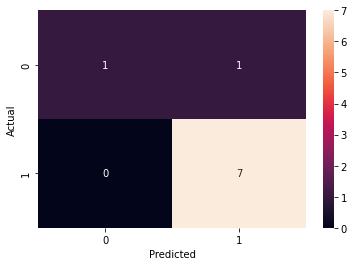

In [11]:
#9.	Menampilkan confusion matrix
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)

In [12]:
#10.	Menampilkan akurasi dari prediksi
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
plt.show()

Accuracy:  0.8888888888888888


In [13]:
#11.	Melihat data yang diuji
print (X_test)

    Penilaian_dari_pelanggan  Penilaian_dari_karyawan  Penilaian_dari_petinggi
2                        700                        1                        1
28                       796                        4                        2
13                       649                        4                        3
10                       632                        3                        1
26                       627                        4                        1
24                       695                        3                        3
27                       770                        4                        2
11                       800                        2                        1
17                       536                        3                        3


In [14]:
#12.	Melihat hasil prediksi
print (y_pred)

[1 1 1 1 1 1 1 1 0]


# Prediksi dengan menambah data baru

In [22]:
#13.	Menguji data yang baru
new_predict = {'Penilaian_dari_pelanggan': [720, 600],
               'Penilaian_dari_karyawan':[2, 4],
               'Penilaian_dari_petinggi':[1, 3]
                  }

df2 = pd.DataFrame(new_predict,columns= ['Penilaian_dari_pelanggan','Penilaian_dari_karyawan','Penilaian_dari_petinggi'])

In [23]:
#14.	Menerapkan regresi logistik pada data yang baru
y_pred=logistic_regression.predict(df2)

In [24]:
#15.	Menampilkan data baru yang akan diuji
print (df2)

   Penilaian_dari_pelanggan  Penilaian_dari_karyawan  Penilaian_dari_petinggi
0                       720                        2                        1
1                       600                        4                        3


In [25]:
#16.	Menampilkan hasil data prediksi data baru yang baru saja diuji
print (y_pred)

[1 1]


# Latihan 2

In [26]:
new_predict = {'Penilaian_dari_pelanggan': [560, 660, 700, 600],
               'Penilaian_dari_karyawan':[2, 2, 4, 1],
               'Penilaian_dari_petinggi':[1, 2, 2, 1]
                  }

df2 = pd.DataFrame(new_predict,columns= ['Penilaian_dari_pelanggan','Penilaian_dari_karyawan','Penilaian_dari_petinggi'])

In [27]:
y_pred=logistic_regression.predict(df2)

In [28]:
print (df2)

   Penilaian_dari_pelanggan  Penilaian_dari_karyawan  Penilaian_dari_petinggi
0                       560                        2                        1
1                       660                        2                        2
2                       700                        4                        2
3                       600                        1                        1


In [29]:
print (y_pred)

[0 1 1 0]
